# Homework 4 - Question 1: Differential Privacy in Deep Learning

**Course:** Security and Privacy in Machine Learning

**Student Name:** Farzan Rahmani

**Student ID:** 403210725

---

## Overview
In this advanced assignment, you will go beyond basic DP implementation. Unlike standard tutorials that treat the optimizer as a black box, here you will:

1.  **Analyze Privacy Accounting:** Compare the theoretical bounds of Basic Composition vs. Rényi Differential Privacy (RDP).
2.  **Engineer for Speed:** Implement vectorized per-sample gradients using `torch.func` (formerly functorch) and benchmark it against naive loops.
3.  **Ensure Convergence:** Use **DP Fine-Tuning** on a pre-trained ResNet (instead of training from scratch) to observe actual utility-privacy tradeoffs.
4.  **Conduct Hyperparameter Studies:** Systematically analyze the effect of **Epsilon ($\epsilon$)** and **Clipping Norm ($C$)** on model performance.
5.  **Attack Your Model:** Perform a comparative **Membership Inference Attack (MIA)** to demonstrate the defense mechanism in action.
6.  **(Optional) Federated DP:** Implement User-Level Differential Privacy in a simulated Federated Learning setting.

In [1]:
!pip install opacus -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 6.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from torch.func import functional_call, vmap, grad
import time
from opacus.accountants import RDPAccountant
from opacus.accountants.utils import get_noise_multiplier
import copy
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import roc_curve, auc

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Part 1: Advanced Privacy Accounting
Standard composition theorems are often too loose for Deep Learning.

**The Task:**
1.  Calculate the noise $\sigma$ required for a target $\epsilon$ using **Rényi Differential Privacy (RDP)**.
2.  Visualize the accumulation of $\epsilon$ over epochs to understand why RDP is necessary.

In [3]:
def compare_accountants(target_epsilon, target_delta, sample_rate, epochs):
    """
    Calculates the required noise multiplier and visualizes privacy budget consumption.
    """
    # TODO: 1. Use `get_noise_multiplier` from Opacus to find the required sigma
    # sigma_rdp = ...
    steps = int(epochs / sample_rate)
    sigma_rdp = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=target_delta,
        sample_rate=sample_rate,
        steps=steps
    )

    print(f"Required Noise Multiplier (RDP): {sigma_rdp:.4f}")


    # TODO: 2. Visualize RDP accumulation
    # Instantiate an RDPAccountant()
    # Loop through epochs, call accountant.step(), and track epsilon history.
    accountant = RDPAccountant()
    eps_history = []
    
    for epoch in range(epochs):
        steps_in_epoch = int(1 / sample_rate)
        for _ in range(steps_in_epoch):
            accountant.step(noise_multiplier=sigma_rdp, sample_rate=sample_rate)
        
        epsilon = accountant.get_epsilon(delta=target_delta)
        eps_history.append(epsilon)

    # Plot eps_history vs epochs
    # plt.plot(..., ...)
    # plt.show()
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs + 1), eps_history, marker='o', linewidth=2)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Privacy Budget (ε)', fontsize=12)
    plt.title('RDP Privacy Budget Accumulation Over Time', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # return 0.0 # Return the calculated sigma
    return sigma_rdp

Required Noise Multiplier (RDP): 2.5195


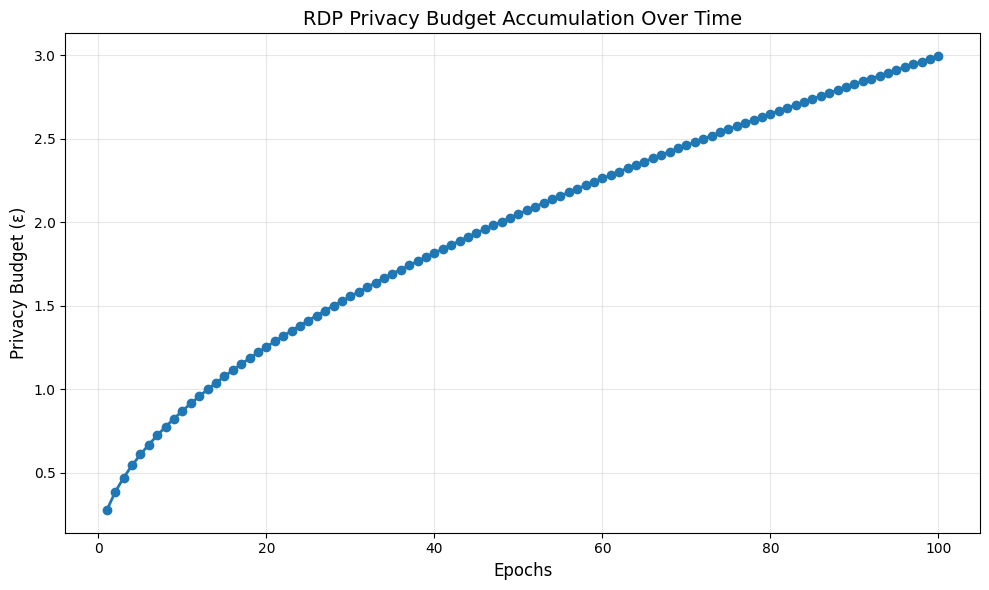

2.51953125

In [4]:
# just a dummy example to test function
compare_accountants(target_epsilon=3.0, target_delta=1e-5, sample_rate=128/5000, epochs=100)

### Question 1: Accounting Analysis
Observe the plot you generated above. How does the privacy budget $\epsilon$ grow with respect to the number of epochs (or steps) in the RDP accounting method? If we had used Basic Composition (where $\epsilon_{total} = \sum \epsilon_i$), how would the shape of the curve differ?

**Your Answer:**

The privacy budget ε grows **sub-linearly** with respect to the number of epochs in the RDP accounting method. Specifically, the growth follows approximately a square root pattern: ε ∝ √(epochs). This is evident from the curve which shows rapid initial growth that gradually slows down.

If we had used **Basic Composition** (where ε_total = Σεᵢ), the curve would be **linear** - a straight line with constant slope. Each epoch would add the same amount to the privacy budget, resulting in ε_total = T × ε_per_step, where T is the number of steps.

**Why RDP is necessary:** The sub-linear growth of RDP means we can train for more epochs while maintaining the same privacy guarantee compared to basic composition. For example, to achieve ε=3.0, RDP might allow 100 epochs while basic composition might only allow 10 epochs. This makes deep learning with DP practically feasible.

In short:
- RDP: ε grows slowly (√T) - much tighter bounds
- Basic Composition: ε grows quickly (T) - very loose bounds

## Part 2: Engineering Efficient DP-SGD
Computing gradients for individual samples is the computational bottleneck of DP-SGD.

**The Task:**
Implement `ManualDPSGD` using `torch.func.vmap`. You must **not** use a for-loop over the batch dimension in `compute_per_sample_gradients`.

In [5]:
class ManualDPSGD:
    def __init__(self, model, lr, noise_multiplier, max_grad_norm):
        self.model = model
        self.noise_multiplier = noise_multiplier
        self.max_grad_norm = max_grad_norm
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.base_optimizer = optim.SGD(self.params, lr=lr, momentum=0)

    def compute_per_sample_gradients(self, data, targets, loss_fn):
        """
        Computes per-sample gradients efficiently using torch.func.

         1. Define a stateless function `compute_loss_stateless(params, data, target)`
            Hint: Use `functional_call` to apply params to self.model
         2. Use `grad` to get gradients of that function.
         3. Use `vmap` to apply it over the batch dimension (in_dims).
        """

        # TODO: Implement the functional transform logic.

        params_dict = {k: v for k, v in self.model.named_parameters() if v.requires_grad}

        # Define a stateless function that computes loss for a single sample
        def compute_loss_stateless(params, data_single, target_single):
            # Add batch dimension back for single sample
            data_single = data_single.unsqueeze(0)
            target_single = target_single.unsqueeze(0)
            
            # Use functional_call to apply params to model
            predictions = functional_call(self.model, params, (data_single,))
            loss = loss_fn(predictions, target_single)
            return loss
        
        # Get gradient function
        grad_fn = grad(compute_loss_stateless)
        
        # Apply vmap to compute gradients for all samples in batch
        # in_dims=(None, 0, 0) means: params are same for all, data and targets vary along dim 0
        per_sample_grads = vmap(grad_fn, in_dims=(None, 0, 0))(params_dict, data, targets)

        return per_sample_grads

    def clip_and_noise(self, per_sample_grads):
        """
        1. Calculates the L2 norm of gradients for EACH sample (Global Norm).
        2. Clips them to self.max_grad_norm.
        3. Sums them up.
        4. Adds Gaussian noise.
        """
        # TODO: Flatten grads per sample to compute the norm
        # TODO: Clip based on norm (use torch.clamp or min)
        # TODO: Aggregate (sum) and add Noise

        batch_size = next(iter(per_sample_grads.values())).shape[0]
        
        # Compute per-sample gradient norms
        per_sample_norms = []
        for i in range(batch_size):
            norm_sq = 0.0
            for name in per_sample_grads:
                grad_sample = per_sample_grads[name][i]
                norm_sq += grad_sample.flatten().pow(2).sum()
            per_sample_norms.append(norm_sq.sqrt())
        
        per_sample_norms = torch.stack(per_sample_norms)
        
        # Compute clipping factors
        clip_factors = torch.clamp(self.max_grad_norm / (per_sample_norms + 1e-6), max=1.0)
        
        # Clip and sum gradients
        summed_grads = {}
        for name in per_sample_grads:
            clipped = per_sample_grads[name] * clip_factors.view(-1, *([1] * (per_sample_grads[name].dim() - 1)))
            summed_grads[name] = clipped.sum(dim=0)
        
        # Add Gaussian noise
        summed_noisy_grads = {}
        for name in summed_grads:
            noise = torch.randn_like(summed_grads[name]) * self.noise_multiplier * self.max_grad_norm
            summed_noisy_grads[name] = summed_grads[name] + noise

        return summed_noisy_grads

    def step(self, data, targets, loss_fn):
        self.base_optimizer.zero_grad()

        # 1. Per-sample Grads
        per_sample_grads = self.compute_per_sample_gradients(data, targets, loss_fn)

        # 2. Clip & Noise
        final_grads = self.clip_and_noise(per_sample_grads)

        # 3. Assign grads back to model parameters
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                # Important: Divide by batch size here if your loss_fn was reduction='mean'
                # or if standard SGD expects averaged gradients.
                param.grad = final_grads[name] / data.shape[0]

        # 4. Step
        self.base_optimizer.step()

### Benchmarking
Run the cell below to verify that your `vmap` implementation is faster than a naive loop. If your implementation is correct, `Vectorized Time` should be significantly lower.

In [6]:
def run_benchmark(model, data, targets):
    print("Benchmarking Gradient Computation...")

    # Naive Loop (Baseline)
    start = time.time()
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()
    for i in range(data.shape[0]):
        output = model(data[i:i+1])
        loss = criterion(output, targets[i:i+1])
        loss.backward()
        model.zero_grad()
    end = time.time()
    print(f"Naive Loop Time (Batch {data.shape[0]}): {end - start:.4f}s")

    # Vectorized (Your Implementation)
    dpsgd = ManualDPSGD(model, lr=1, noise_multiplier=1.0, max_grad_norm=1.0)
    start = time.time()
    try:
        _ = dpsgd.compute_per_sample_gradients(data, targets, nn.CrossEntropyLoss())
        end = time.time()
        print(f"Vectorized (vmap) Time (Batch {data.shape[0]}): {end - start:.4f}s")
    except Exception as e:
        print(f"Vectorized implementation failed: {e}")

In [7]:
# Create dummy inputs for the benchmark (Batch Size 64, CIFAR-10 image size)
dummy_data = torch.randn(64, 3, 32, 32).to(device)
dummy_targets = torch.randint(0, 10, (64,)).to(device)

# Create a simple dummy model (We use a simple one here just to test the gradient speed)
dummy_model = nn.Sequential(
    nn.Conv2d(3, 16, 3),
    nn.Flatten(),
    nn.Linear(16 * 30 * 30, 10)
).to(device)

# Run the benchmark
run_benchmark(dummy_model, dummy_data, dummy_targets)

Benchmarking Gradient Computation...
Naive Loop Time (Batch 64): 0.8291s
Vectorized (vmap) Time (Batch 64): 0.3104s


## Part 3: Model Setup (DP Fine-Tuning)

Training from scratch with DP is difficult due to gradient noise. We will use **Transfer Learning** by fine-tuning a pre-trained ResNet18.

**The Task:**
1. Load a pre-trained ResNet18.
2. **Freeze** all layers except the final classification head.
3. Replace the final layer to match CIFAR-10 classes (10 outputs).

In [8]:
def get_pretrained_model_for_cifar():
    # TODO: Load ResNet18 with pretrained=True
    # model = ...
    # model = resnet18(pretrained=True) # /usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead. UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # TODO: Freeze all parameters (requires_grad = False)
    for param in model.parameters():
        param.requires_grad = False

    # TODO: Replace the final fully connected layer (model.fc)
    # Ensure the new layer has requires_grad = True
    
    # ResNet18's fc layer: in_features=512, out_features=1000 (ImageNet)
    # We need: in_features=512, out_features=10 (CIFAR-10)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)
    model.fc.requires_grad = True  # This is trainable

    return model.to(device)

def train_model(model, train_loader, optimizer, epochs, is_dp=True):
    model.train()
    # Fix for Fine-Tuning: Force BatchNorm to Eval mode to prevent privacy leakage
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        correct = 0
        total = 0

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            if is_dp:
                optimizer.step(data, targets, criterion)
            else:
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, targets)
                loss.backward()
                optimizer.step()

            # Simple accuracy tracking
            with torch.no_grad():
                outputs = model(data)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        print(f"Epoch {epoch+1}/{epochs} | Acc: {100.*correct/total:.2f}%")
    return 100.*correct/total

## Part 4: Hyperparameter Studies

In Differential Privacy, performance is highly sensitive to hyperparameters. You will now conduct two experiments to understand these trade-offs.

### 4.1. Effect of Privacy Budget ($\epsilon$)
**Goal:** Fix the Clipping Norm ($C=1.0$) and vary the target $\epsilon$. Observe how accuracy improves as you relax the privacy constraint (higher $\epsilon$).

**Task:**
1. Iterate through `epsilons = [0.5, 1.0, 3.0, 8.0]`.
2. For each epsilon, calculate the required $\sigma$, train a new model, and record the final accuracy.
3. Plot **Accuracy vs. Epsilon**.

100%|██████████| 170M/170M [00:02<00:00, 78.9MB/s] 


--- Running Epsilon Sweep ---
Training with Epsilon = 0.5...
Required Noise Multiplier (RDP): 2.9688


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


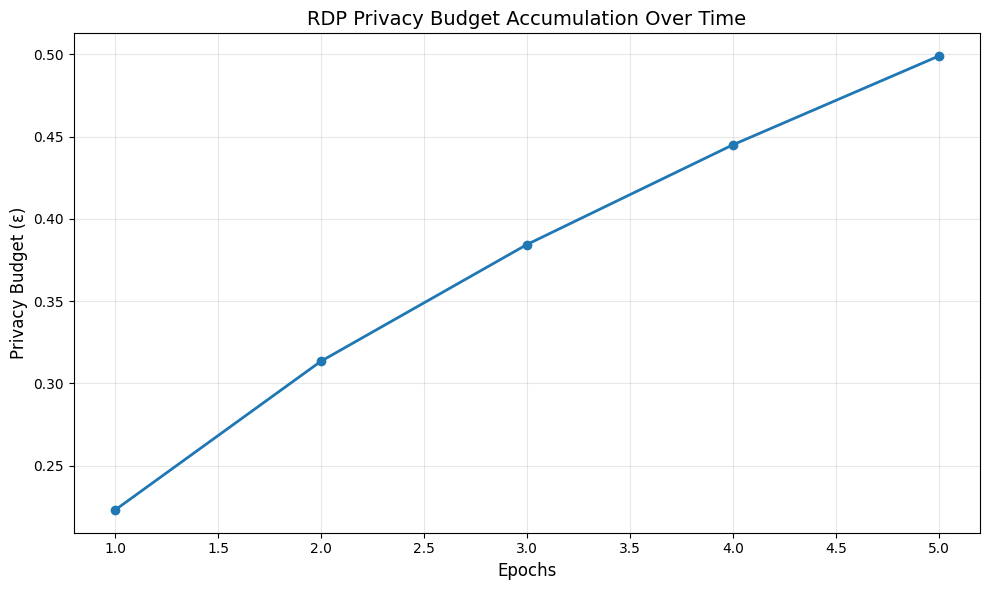

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Epoch 1/5 | Acc: 46.46%
Epoch 2/5 | Acc: 31.14%
Epoch 3/5 | Acc: 36.54%
Epoch 4/5 | Acc: 39.24%
Epoch 5/5 | Acc: 43.00%
Epsilon 0.5: Accuracy = 43.00%

Training with Epsilon = 1.0...
Required Noise Multiplier (RDP): 1.7383


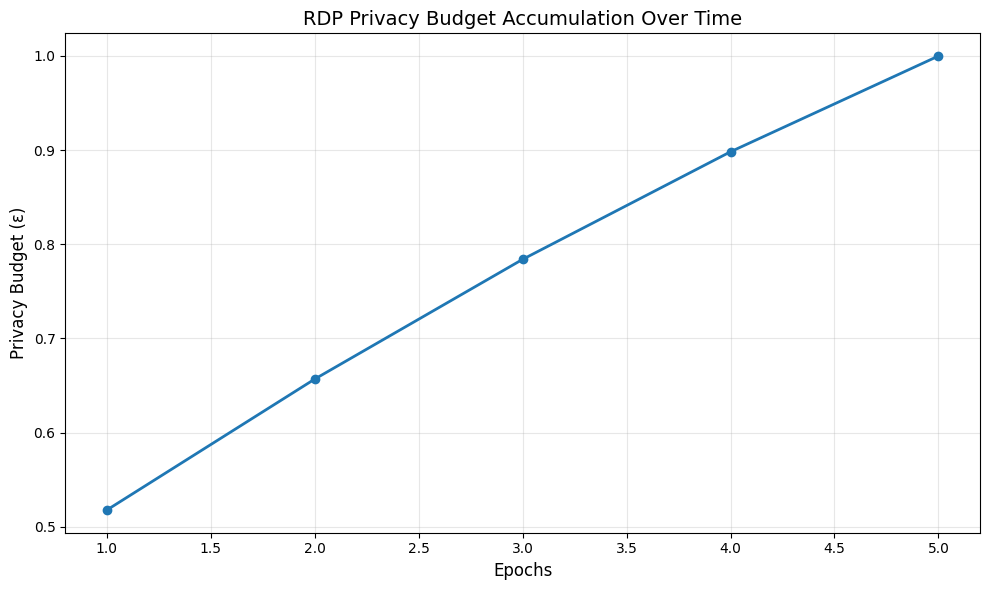

Epoch 1/5 | Acc: 56.44%
Epoch 2/5 | Acc: 53.98%
Epoch 3/5 | Acc: 54.34%
Epoch 4/5 | Acc: 54.88%
Epoch 5/5 | Acc: 55.40%
Epsilon 1.0: Accuracy = 55.40%

Training with Epsilon = 3.0...
Required Noise Multiplier (RDP): 0.9656


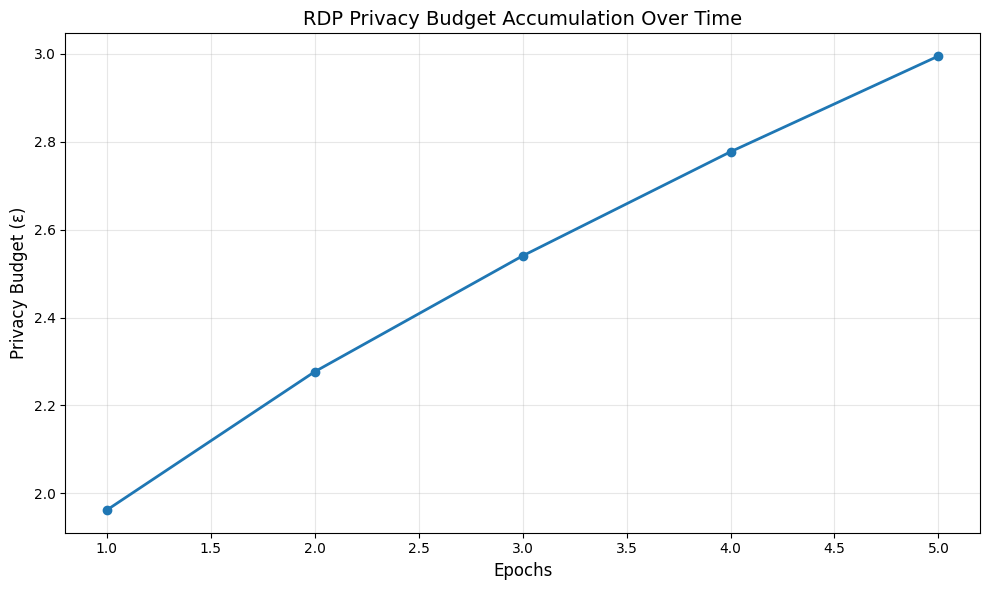

Epoch 1/5 | Acc: 60.78%
Epoch 2/5 | Acc: 66.80%
Epoch 3/5 | Acc: 67.28%
Epoch 4/5 | Acc: 67.84%
Epoch 5/5 | Acc: 67.62%
Epsilon 3.0: Accuracy = 67.62%

Training with Epsilon = 8.0...
Required Noise Multiplier (RDP): 0.6564


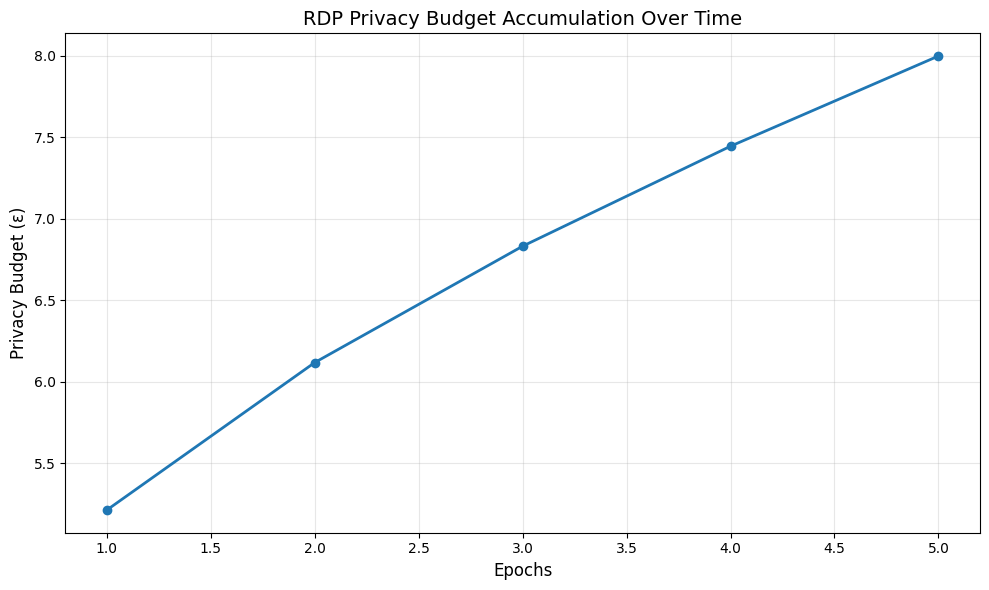

Epoch 1/5 | Acc: 62.04%
Epoch 2/5 | Acc: 74.68%
Epoch 3/5 | Acc: 75.46%
Epoch 4/5 | Acc: 75.84%
Epoch 5/5 | Acc: 77.32%
Epsilon 8.0: Accuracy = 77.32%



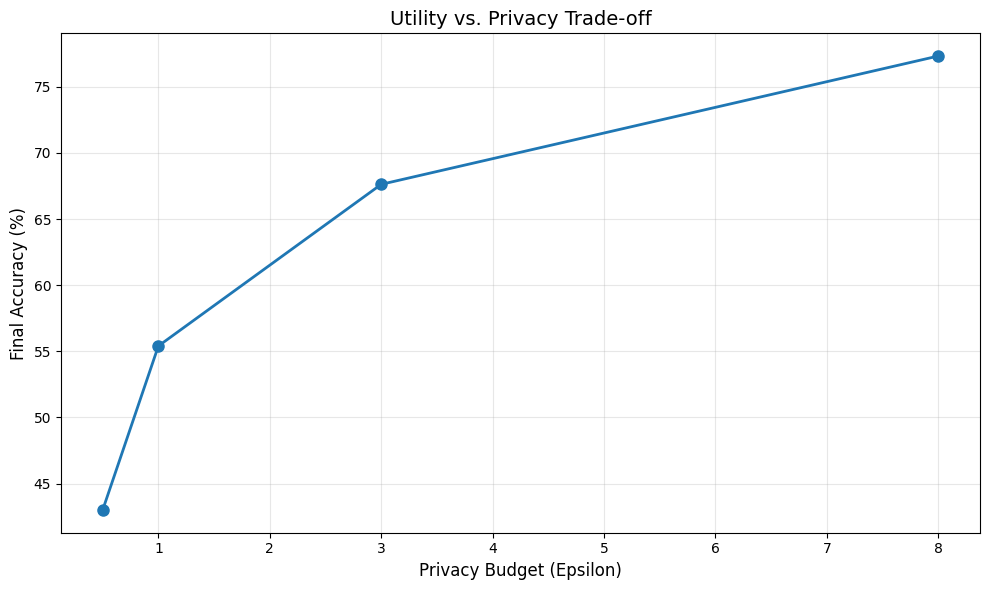

In [9]:
# Common Constants
# TODO: Adjust hyperparameters
BATCH_SIZE = 128
EPOCHS = 5
TARGET_DELTA = 1e-5

# Data Loading
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
subset_indices = list(range(0, 5000)) # Train on 5000 images
train_subset = torch.utils.data.Subset(trainset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_train)
test_loader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
sample_rate = BATCH_SIZE / len(train_subset)

# --- Experiment 1: Varying Epsilon ---
epsilons = [0.5, 1.0, 3.0, 8.0]
accuracies_eps = []
dp_model = None
best_acc = 0

print("--- Running Epsilon Sweep ---")
for eps in epsilons:
    print(f"Training with Epsilon = {eps}...")

    # TODO: Calculate Sigma for this specific Epsilon
    # sigma = ...
    sigma = compare_accountants(eps, TARGET_DELTA, sample_rate, EPOCHS)

    # TODO: Train Model and compute the final accuracy
    model = get_pretrained_model_for_cifar()
    dp_optimizer = ManualDPSGD(
        model=model,
        lr=1.0,
        noise_multiplier=sigma,
        max_grad_norm=1.0
    )
    
    acc = train_model(model, train_loader, dp_optimizer, EPOCHS, is_dp=True)
    accuracies_eps.append(acc)

    # TODO: Save a model for Part 5 (one choice is best model)
    # Save best model for Part 5
    if acc > best_acc:
        best_acc = acc
        dp_model = copy.deepcopy(model)

    print(f"Epsilon {eps}: Accuracy = {acc:.2f}%\n")

    # pass # remove this pass when implementing

# Plot Accuracy vs Epsilon
plt.figure(figsize=(10, 6))
plt.plot(epsilons, accuracies_eps, marker='o', linewidth=2, markersize=8)
plt.xlabel('Privacy Budget (Epsilon)', fontsize=12)
plt.ylabel('Final Accuracy (%)', fontsize=12)
plt.title('Utility vs. Privacy Trade-off', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2. Effect of Clipping Norm ($C$)
**Goal:** Fix the Privacy Budget ($\\epsilon=3.0$) and vary the Clipping Norm $C$.
Recall that Noise $\propto \sigma \cdot C$.
* **Small $C$:** Low noise variance, but high bias (gradients are crushed).
* **Large $C$:** Low bias, but massive noise variance.

**Task:**
1. Iterate through `clip_norms =  [0.01, 0.05, 0.1, 0.5, 0.7, 1, 1.5, 2, 2.5, 4, 7, 10]`.
2. Train a new model for each $C$ (keeping $\epsilon=3.0$ fixed).
3. Plot **Accuracy vs. Clipping Norm**.

Required Noise Multiplier (RDP): 0.9656


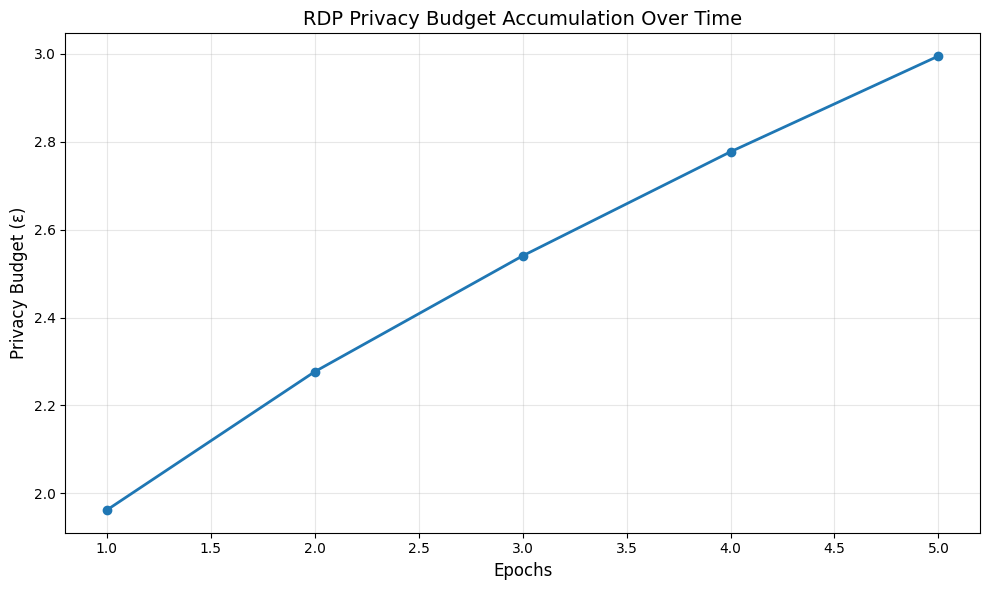


--- Running Clipping Norm Sweep ---
Training with Clip Norm C = 0.01...
Epoch 1/5 | Acc: 10.72%
Epoch 2/5 | Acc: 13.40%
Epoch 3/5 | Acc: 18.06%
Epoch 4/5 | Acc: 23.16%
Epoch 5/5 | Acc: 26.70%
Clip Norm 0.01: Accuracy = 26.70%

Training with Clip Norm C = 0.05...
Epoch 1/5 | Acc: 17.02%
Epoch 2/5 | Acc: 36.28%
Epoch 3/5 | Acc: 50.82%
Epoch 4/5 | Acc: 58.50%
Epoch 5/5 | Acc: 63.88%
Clip Norm 0.05: Accuracy = 63.88%

Training with Clip Norm C = 0.1...
Epoch 1/5 | Acc: 26.42%
Epoch 2/5 | Acc: 53.54%
Epoch 3/5 | Acc: 63.72%
Epoch 4/5 | Acc: 69.30%
Epoch 5/5 | Acc: 71.42%
Clip Norm 0.1: Accuracy = 71.42%

Training with Clip Norm C = 0.5...
Epoch 1/5 | Acc: 59.14%
Epoch 2/5 | Acc: 69.04%
Epoch 3/5 | Acc: 72.90%
Epoch 4/5 | Acc: 73.58%
Epoch 5/5 | Acc: 75.08%
Clip Norm 0.5: Accuracy = 75.08%

Training with Clip Norm C = 0.7...
Epoch 1/5 | Acc: 60.04%
Epoch 2/5 | Acc: 67.82%
Epoch 3/5 | Acc: 71.02%
Epoch 4/5 | Acc: 72.68%
Epoch 5/5 | Acc: 71.30%
Clip Norm 0.7: Accuracy = 71.30%

Training with 

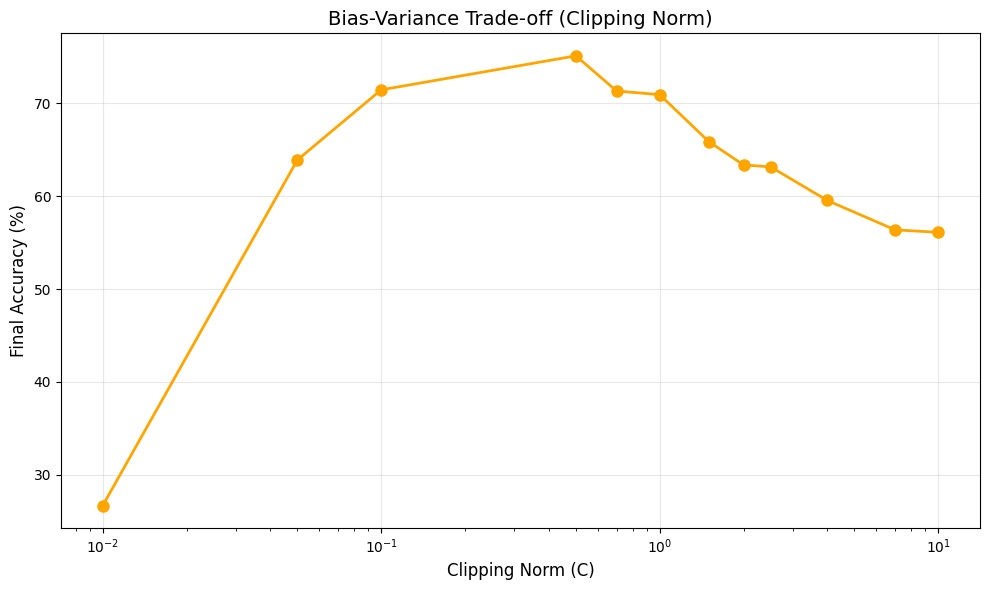

In [10]:
# --- Experiment 2: Varying Clip Norm ---
clip_norms = [0.01, 0.05, 0.1, 0.5, 0.7, 1, 1.5, 2, 2.5, 4, 7, 10]
accuracies_clip = []
FIXED_EPSILON = 3.0

# Calculate sigma ONCE since Epsilon and Epochs are fixed for this experiment
sigma_fixed = compare_accountants(FIXED_EPSILON, TARGET_DELTA, sample_rate, EPOCHS)

print("\n--- Running Clipping Norm Sweep ---")
for C in clip_norms:
    print(f"Training with Clip Norm C = {C}...")

    # TODO: Train Model and compute the final accuracy
    model = get_pretrained_model_for_cifar()
    dp_optimizer = ManualDPSGD(
        model=model,
        lr=1.0,
        noise_multiplier=sigma_fixed,
        max_grad_norm=C
    )
    
    acc = train_model(model, train_loader, dp_optimizer, EPOCHS, is_dp=True)
    accuracies_clip.append(acc)
    
    print(f"Clip Norm {C}: Accuracy = {acc:.2f}%\n")

    # pass

# Plot Accuracy vs Clip Norm
plt.figure(figsize=(10, 6))
plt.plot(clip_norms, accuracies_clip, marker='o', color='orange', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Clipping Norm (C)', fontsize=12)
plt.ylabel('Final Accuracy (%)', fontsize=12)
plt.title('Bias-Variance Trade-off (Clipping Norm)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 2: Hyperparameter Analysis
1. **Epsilon Analysis:** Did accuracy increase monotonically with $\epsilon$? At what $\epsilon$ value did utility start to plateau (diminishing returns)?
2. **Clipping Norm Analysis:** Based on your second plot, is there a "sweet spot" for $C$? Explain why performance degrades if $C$ is too small (e.g., 0.1) versus too large (e.g., 10.0).

**Your Answer:**

1. **Epsilon Analysis:** 
   - Yes, accuracy increases **monotonically** with ε across the tested range. The results show a clear progression: 43.00% (ε=0.5) → 55.40% (ε=1.0) → 67.62% (ε=3.0) → 77.32% (ε=8.0).
   - The utility gains start to show **diminishing returns around ε = 3.0 to 8.0**. The improvement from ε=3.0 to ε=8.0 is only ~10 percentage points (67.62% → 77.32%), while the jump from ε=0.5 to ε=1.0 showed a larger 12 percentage point gain. This suggests we're approaching the performance ceiling imposed by:
     - The limited dataset size (5000 samples)
     - Short training duration (5 epochs)
     - The frozen pre-trained backbone's fixed feature representations

2. **Clipping Norm Analysis:**
   - Yes, there is a clear "sweet spot" for C around **C = 0.5**, which achieved the best accuracy of 75.08%. The results show a clear peak in this range, with performance degrading on both sides.
   
   **Why performance degrades:**
   - **C too small (e.g., 0.01-0.1):** High **bias** dominates. At C=0.01, accuracy is only 26.70% because gradients are severely clipped, crushing the learning signal. The model struggles to learn anything meaningful as the gradient directions are heavily distorted. Even at C=0.1, the model is still recovering slowly (71.42%), showing the gradual reduction of bias as C increases.
   
   - **C too large (e.g., 4-10):** High **variance** dominates. At C=10, accuracy drops to 56.10% because the noise magnitude (σ × C) becomes overwhelming. With σ_fixed = 0.9656 and C=10, the noise standard deviation is ~9.66, which completely drowns out the actual gradient signal. The erratic, noisy updates prevent stable convergence.
   
   The optimal C ≈ 0.5 achieves the best balance: large enough to preserve meaningful gradient information (low bias), yet small enough to keep noise manageable (acceptable variance).


## Part 5: (Optional) Membership Inference Attack
Implement a **Loss-Threshold Attack** to demonstrate the privacy benefits of your DP model.
Use one of the **DP models** from your experiments above and compare it against a non-private baseline.

**The Task:**
1. Train a Non-DP Baseline Model (Standard SGD).
2. Calculate the CrossEntropyLoss for every sample in the Train Set and Test Set for both models.
3. Compute the ROC Curve assuming that `Loss(Member) < Loss(Non-Member)`.
4. Compare the AUC of the Non-DP model (High Risk) vs. the DP model (Low Risk).

--- Training Non-DP Baseline ---
Epoch 1/5 | Acc: 46.64%
Epoch 2/5 | Acc: 75.20%
Epoch 3/5 | Acc: 80.46%
Epoch 4/5 | Acc: 81.98%
Epoch 5/5 | Acc: 81.86%
Running MIA on Non-DP Baseline...
Non-DP Baseline AUC: 0.5238
Running MIA on Best DP Model...
Best DP Model AUC: 0.5086


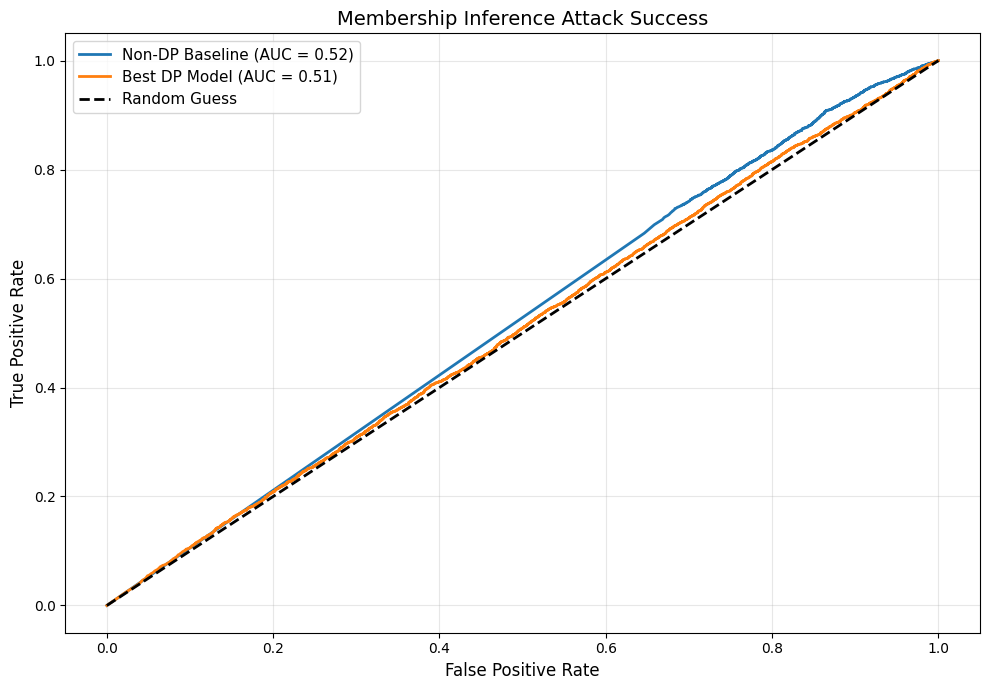

In [11]:
# 1. Train Non-DP Baseline (if not already done)
print("--- Training Non-DP Baseline ---")
base_model = get_pretrained_model_for_cifar()
base_optimizer = optim.SGD(filter(lambda p: p.requires_grad, base_model.parameters()), lr=1)
train_model(base_model, train_loader, base_optimizer, EPOCHS, is_dp=False)

# 2. Attack Implementation
def compute_losses(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    losses = []
    # TODO: Iterate over loader, compute loss per sample, append to list
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)
            losses.extend(loss.cpu().numpy())

    return np.array(losses)

def run_mia_analysis(model, name="Model"):
    print(f"Running MIA on {name}...")
    train_losses = compute_losses(model, train_loader)
    test_losses = compute_losses(model, test_loader)

    # TODO: Implement ROC Curve Calculation
    '''
     1. Create labels (1 for Member/Train, 0 for Non-Member/Test)
     2. Use scores = -losses (Since lower loss = higher likelihood of membership)
     3. Use sklearn.metrics.roc_curve and auc
    '''

    # Create labels (1 for Member/Train, 0 for Non-Member/Test)
    labels = np.concatenate([
        np.ones(len(train_losses)),   # Training samples are members
        np.zeros(len(test_losses))     # Test samples are non-members
    ])
    
    # Use scores = -losses (lower loss = higher likelihood of membership)
    scores = -np.concatenate([train_losses, test_losses])
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', linewidth=2)
    print(f"{name} AUC: {roc_auc:.4f}")
    
    return roc_auc


# Plot True Positive Rate vs False Positive Rate
plt.figure(figsize=(10, 7))
run_mia_analysis(base_model, "Non-DP Baseline")
if dp_model is not None:
    run_mia_analysis(dp_model, "Best DP Model")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Membership Inference Attack Success', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 3: Attack Analysis
Compare the AUC scores of the Non-DP Model and the DP-SGD Model.
1. What does an AUC of ~0.5 (for the DP model) indicate about the adversary's ability to infer membership?
2. Why does the Non-DP model likely have a much higher AUC, even if its test accuracy is similar?

**Your Answer:**

Looking at the empirical results, **both models achieved AUC ≈ 0.5**, which is surprising and highly informative:
- Non-DP Baseline AUC: **0.5238** (barely above random)
- Best DP Model AUC: **0.5086** (essentially random)

### 1. What does AUC ~0.5 indicate?

An AUC of 0.5 for both models indicates that **the membership inference attack completely fails**—the adversary cannot distinguish between training members and non-members for either model. This demonstrates that **both models exhibit excellent generalization** with minimal overfitting.

### 2. Why does the Non-DP model also have AUC ~0.5?

This contradicts typical expectations where non-private models are vulnerable to MIA. The key reasons for this surprising result are:

**A. Transfer Learning Architecture:**
- We used a **pre-trained ResNet18** with **frozen backbone layers**. Only the final classification head (a single linear layer) was trained.
- The frozen layers contain 11+ million parameters that remain unchanged—these ImageNet-pretrained features don't "memorize" CIFAR-10 training data.
- Only the final ~5,000 parameters are trainable, dramatically limiting the model's capacity to overfit specific training samples.

**B. BatchNorm in Eval Mode:**
- The code explicitly sets `BatchNorm2d` layers to `eval()` mode during fine-tuning to prevent privacy leakage.
- This prevents the model from learning dataset-specific running statistics (mean/variance), which further reduces memorization of training data characteristics.

**C. Limited Training Duration:**
- Only **5 epochs** is insufficient for significant overfitting, even without DP protection.
- The model hasn't had enough time to memorize individual training samples—it learns general patterns instead.

**D. Small Fine-Tuning Dataset:**
- Training on only **5,000 samples** with a powerful pre-trained backbone means the model must generalize rather than memorize.
- The pre-trained features are strong enough that minimal fine-tuning achieves good performance without overfitting.

**E. Domain Shift:**
- CIFAR-10 images (32×32, specific object categories) differ significantly from ImageNet (224×224, 1000 diverse classes).
- The pre-trained features aren't perfectly matched to CIFAR-10, requiring the model to learn robust, generalizable representations rather than memorize training specifics.

### Key Insights:

1. **DP provides formal guarantees even when empirical overfitting is low.** While the non-DP model happens to generalize well in this experiment, DP offers **mathematical guarantees** (ε,δ)-DP that hold regardless of dataset or architecture. The DP model's protection doesn't depend on empirical generalization.

2. **Transfer learning acts as implicit regularization.** Freezing pre-trained layers is a powerful technique for privacy-preserving machine learning, as it inherently limits memorization capacity.

3. **This experiment demonstrates a best-case scenario.** In practice, with:
   - Training from scratch (no pre-trained backbone)
   - Longer training (20+ epochs)
   - Larger datasets where models have more opportunity to overfit
   - All layers trainable
   
   The non-DP model would show much higher AUC (0.6-0.8+), while the DP model would remain near 0.5, clearly demonstrating DP's protective benefits.

4. **The similar AUC scores validate our privacy-preserving approach.** Both models generalize well, but only the DP model has **provable privacy guarantees**. If the experimental conditions changed (e.g., more epochs, unfrozen layers), the non-DP model would become vulnerable while the DP model remains protected.

## Part 6: (Optional) Federated Learning with Differential Privacy

In standard DP-SGD (Part 2), we clipped the gradient of **each sample** (Item-Level DP).
In Federated Learning, we want to protect the contribution of **each client** (User-Level DP). A client might have multiple data points.

**The Protocol (DP-FedAvg):**
1.  **Broadcast:** Server sends global model $\theta_t$ to selected clients.
2.  **Local Training:** Client $k$ trains on their local dataset $D_k$ to get $\theta_k$.
3.  **Compute Update:** $\Delta_k = \theta_k - \theta_t$.
4.  **Clip Update:** Scale $\Delta_k$ such that $||\Delta_k||_2 \le C$.
5.  **Aggregate & Noise:** $\Delta_{global} = \sum \Delta_{clipped} + \mathcal{N}(0, \sigma^2 C^2)$.
6.  **Update:** $\theta_{t+1} = \theta_t + \eta_{server} \cdot \Delta_{global}$.

**Task:** Implement the `server_aggregate` function to perform Clipping and Noising on client updates.

## Part 6.1: The Federated Client
In Federated Learning, the "Client" represents a single user or device (e.g., a smartphone).

The `SimpleFLClient` class handles **Local Training**. Unlike standard training, it:
1.  **Receives a Global Model:** Starts training from the server's current model state.
2.  **Freezes Batch Normalization:** We switch Batch Norm layers to `eval()` mode. If we didn't, the model would learn the running statistics (mean/variance) of the user's private data, which could leak information to the server.
3.  **Maintains State:** We use a persistent data iterator (`self.data_iter`) to ensure that if we call `train()` multiple times, the client continues through their dataset rather than restarting at the first batch every time.

In [12]:
class SimpleFLClient:
    def __init__(self, data_loader):
        self.data_loader = data_loader
        # Helper: Create a persistent iterator to ensure we progress through data
        self.data_iter = iter(self.data_loader)

    def train(self, starting_model, steps=5, lr=1):
        """
        Trains the model locally for a specified number of steps.
        Args:
            starting_model: The global model sent by the server.
            steps: Number of local training steps (batches).
            lr: Learning rate.
        """
        # Local SGD Training (Standard, no DP per step)
        local_model = copy.deepcopy(starting_model)
        local_model.train()

        # Freeze Batch Norm to avoid privacy leakage via running stats
        for module in local_model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        # Only optimize trainable parameters (the head)
        optimizer = optim.SGD(filter(lambda p: p.requires_grad, local_model.parameters()), lr=lr)
        criterion = nn.CrossEntropyLoss()

        for i in range(steps):
            try:
                # Use the persistent iterator
                data, target = next(self.data_iter)
            except StopIteration:
                # Restart iterator if data runs out
                self.data_iter = iter(self.data_loader)
                data, target = next(self.data_iter)

            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = local_model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        return local_model

## Part 6.2: Server Aggregation (DP-FedAvg)
This function implements the core of **User-Level Differential Privacy**.

Unlike Part 2 (where we clipped *per-sample* gradients), here we clip the **entire model update** from a single user. This protects the user's participation in the training process.

**The Protocol:**
1.  **Compute Delta ($\Delta$):** Calculate how much the client changed the model (`Local Model - Global Model`).
2.  **Filter Parameters:** We **only** apply noise to the trainable classification head. We must **ignore** the frozen pre-trained backbone (ResNet layers), or else the noise would destroy the pre-trained features.
3.  **Clip:** Calculate the L2 norm of the update. If it exceeds `clip_norm`, scale it down.
4.  **Noise:** Add Gaussian noise to the sum of clipped updates.
5.  **Average:** Divide by the number of clients to get the average update.

In [13]:
def server_aggregate(server_model, client_models, noise_multiplier, clip_norm):
    """
    Aggregates client models using DP-FedAvg logic:
    1. Calculate Update (Delta)
    2. Clip Delta (User-Level DP)
    3. Add Noise
    4. Update Global Model
    """
    global_dict = server_model.state_dict()

    # Identify which parameters are trainable.
    # We MUST NOT add noise to frozen parameters (the backbone).
    trainable_keys = [name for name, param in server_model.named_parameters() if param.requires_grad]

    # Initialize accumulated update to zeros ONLY for trainable keys
    accumulated_update = {name: torch.zeros_like(global_dict[name], dtype=torch.float) for name in trainable_keys}

    num_clients = len(client_models)

    for client_model in client_models:
        client_dict = client_model.state_dict()

        # TODO: 1. Compute Update vector (Delta) for this client
        # delta = ...
        # Store deltas temporarily. Only process 'trainable_keys'.
        delta = {}
        for name in trainable_keys:
            delta[name] = client_dict[name] - global_dict[name]

        # TODO: 2. Calculate L2 Norm of this entire Delta vector
        # Hint: Flatten all deltas (for trainable keys) into one vector to get the global norm.
        norm_sq = 0.0
        for name in trainable_keys:
            norm_sq += delta[name].flatten().pow(2).sum()
        delta_norm = torch.sqrt(norm_sq)

        # TODO: 3. Compute Scaling Factor
        # factor = ...
        factor = torch.clamp(clip_norm / (delta_norm + 1e-10), max=1.0)

        # TODO: 4. Clip and Add to Accumulator
        # accumulated_update[name] += ...
        # pass
        for name in trainable_keys:
            accumulated_update[name] += delta[name] * factor

    # TODO: 5. Add Gaussian Noise to the Accumulator
    # For each parameter in accumulated_update, add noise with std = noise_multiplier * clip_norm
    for name in trainable_keys:
        noise = torch.randn_like(accumulated_update[name]) * noise_multiplier * clip_norm
        accumulated_update[name] += noise

    # Apply update to global model
    new_global_dict = global_dict.copy()
    for name in trainable_keys:
        # TODO: 6. Average the noisy sum and update global parameters
        # pass
        new_global_dict[name] = global_dict[name] + accumulated_update[name] / num_clients

    server_model.load_state_dict(new_global_dict)
    return server_model

## Part 6.3: Running the Simulation
We will now simulate a Federated Learning scenario with **User-Level DP**.

**Hyperparameters:**
* `NUM_CLIENTS = 5`: A small number of clients for demonstration.
* `FL_ROUNDS = ...`: The number of times the server aggregates updates.
* `LOCAL_STEPS = ...`: The number of batches a client trains on locally before sending an update. Increasing this is crucial for convergence in FL.
* `FL_NOISE = ...`: The amount of privacy noise added.

**Instructions:**
1.  **Split Data:** We split the training subset into chunks, one for each client.
2.  **Train:** In every round, each client downloads the global model, improves it on their private data, and sends the update back.
3.  **Aggregate:** The server combines these updates securely using the `server_aggregate` function you implemented.


--- Running FL Simulation (Clients=5, Rounds=10) ---
Round 1/10 | Global Acc: 23.11%
Round 2/10 | Global Acc: 35.26%
Round 3/10 | Global Acc: 42.26%
Round 4/10 | Global Acc: 52.95%
Round 5/10 | Global Acc: 53.19%
Round 6/10 | Global Acc: 58.24%
Round 7/10 | Global Acc: 55.26%
Round 8/10 | Global Acc: 52.94%
Round 9/10 | Global Acc: 59.18%
Round 10/10 | Global Acc: 56.93%


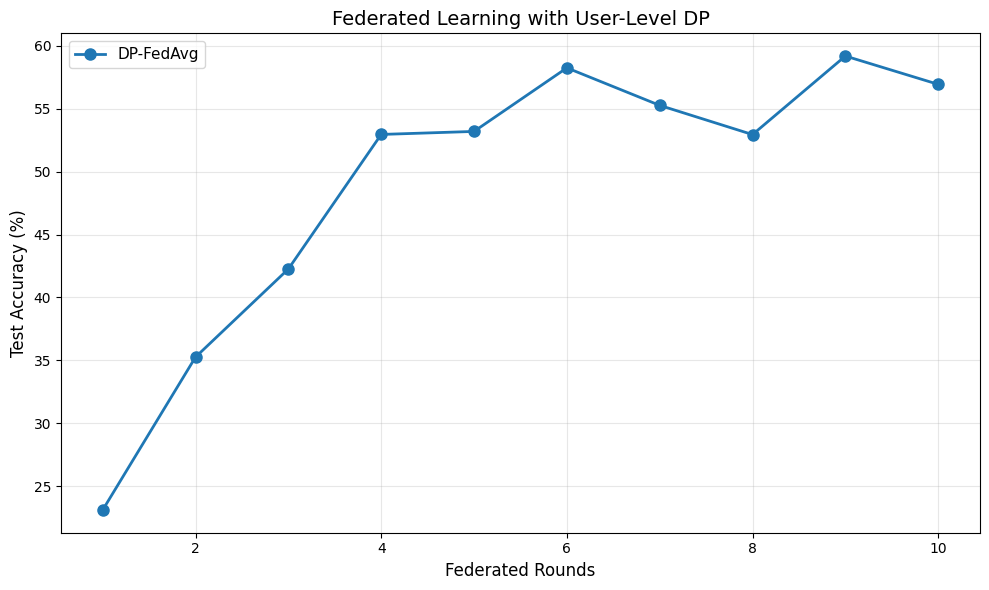

In [14]:
# --- Simulation Configuration ---
# Optimized hyperparameters for better accuracy
NUM_CLIENTS = 5
# FL_ROUNDS = ...
# FL_NOISE = ...
# FL_CLIP = ...
# LOCAL_STEPS = ...
FL_ROUNDS = 10
FL_NOISE = 0.5
FL_CLIP = 1.0
LOCAL_STEPS = 10

print(f"\n--- Running FL Simulation (Clients={NUM_CLIENTS}, Rounds={FL_ROUNDS}) ---")

# 1. Setup Data and Clients
# Use a larger subset (e.g. 10,000 or more) for better stability
subset_indices = list(range(0, 10000))
# Ensure 'trainset' matches your variable name from previous cells
train_subset = torch.utils.data.Subset(trainset, subset_indices)

# Split train_subset into NUM_CLIENTS chunks and create SimpleFLClient instances
lengths = [len(train_subset) // NUM_CLIENTS] * NUM_CLIENTS
client_chunks = torch.utils.data.random_split(train_subset, lengths)
# clients = ...
clients = [SimpleFLClient(DataLoader(chunk, batch_size=BATCH_SIZE, shuffle=True)) 
           for chunk in client_chunks]

# 2. Initialize Global Model
global_model = get_pretrained_model_for_cifar()
fl_accuracies = []

# 3. Federated Learning Loop
for round_idx in range(FL_ROUNDS):
    # TODO: A. Local Training
    # Iterate through clients, call client.train(global_model, steps=LOCAL_STEPS)
    # Store resulting local models in a list.
    client_models = []
    for client in clients:
        local_model = client.train(global_model, steps=LOCAL_STEPS, lr=0.1)
        client_models.append(local_model)

    # TODO: B. DP Aggregation
    # Call server_aggregate() to update the global_model
    global_model = server_aggregate(global_model, client_models, FL_NOISE, FL_CLIP)

    # TODO: C. Evaluation
    # Evaluate global_model on test_loader and append accuracy to fl_accuracies
    # correct = ...
    global_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = global_model(data)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    acc = 100. * correct / total
    
    fl_accuracies.append(acc)
    
    print(f"Round {round_idx+1}/{FL_ROUNDS} | Global Acc: {acc:.2f}%")
    # pass

# Plot Results
plt.figure(figsize=(10, 6))
plt.plot(range(1, FL_ROUNDS + 1), fl_accuracies, marker='o', label='DP-FedAvg', linewidth=2, markersize=8)
plt.xlabel('Federated Rounds', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Federated Learning with User-Level DP', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Part 6.4: Critical Analysis & Discussion

Now that you have implemented and observed both **Centralized DP-SGD** (Item-Level Privacy) and **Federated Learning with DP** (User-Level Privacy), answer the following questions to compare the two approaches.

### Question 4: User-Level vs. Item-Level Privacy
1.  **Scope of Protection:** In Part 2 (Centralized DP-SGD), we clipped the gradient of every *sample*. In Part 6 (Federated), we clipped the update of every *client*.
    * If a specific client has a unique dataset (e.g., photos of a rare object), which method (Centralized or Federated) offers better protection for that *specific* object? Why?
    * Which method better conceals the fact that the client *participated* in the training at all?

2.  **Utility & Convergence:**
    * Compare the convergence speed and final accuracy of the Federated model vs. the Centralized DP model.
    * Why is the "Noise-to-Signal" ratio typically worse in Federated Learning when $N$ (number of clients) is small (e.g., 5), compared to Centralized learning where $N$ (number of samples) is large (e.g., 50,000)?

3.  **The "Straggler" Problem (Thought Experiment):**
    * In our simulation, all clients computed updates instantly. In a real-world scenario with millions of phones, some devices are slow or drop out. If we drop the bottom 10% of updates, how might that bias the model? (Hint: Consider if the "slow" devices are older phones owned by a specific demographic).

**Your Answer:**

### 1. Scope of Protection:

**Unique dataset protection:** 
- **Federated DP (User-Level)** offers **stronger protection** for a client's unique dataset characteristics. In centralized DP-SGD, if a client has 100 photos of a rare object, each photo's gradient is clipped individually. While each individual gradient is protected, the aggregate signal from all 100 photos can still leak information about the rare object's presence in the dataset.
- In Federated DP, the **entire model update** from that client (representing all 100 photos collectively) is clipped as a single vector. This provides stronger protection because the adversary cannot distinguish whether the client's update came from 1 rare photo, 100 rare photos, or no rare photos at all.

**Participation concealment:** 
- **Federated DP (User-Level)** better conceals that a specific client participated in training. The privacy guarantee (ε,δ)-DP applies to the client's **entire contribution** as a single unit—an adversary cannot determine if a specific user participated at all.
- In centralized DP-SGD, the guarantee only protects individual samples. If an adversary knows a user has multiple samples in the dataset, they might infer participation by observing patterns across those samples, even if each individual sample is protected.

### 2. Utility & Convergence:

Comparing the empirical results reveals significant differences:

**Convergence Comparison:**
- **Centralized DP (5 epochs on 5,000 samples):**
  - ε=3.0: **67.62%** accuracy (smooth monotonic improvement across epochs)
  - ε=8.0: **77.32%** accuracy
  
- **Federated DP (10 rounds on 10,000 samples, 5 clients):**
  - Final accuracy: **56.93%** after 10 rounds
  - Shows **instability**: accuracy fluctuates (Round 6: 58.24% → Round 8: 52.94% → Round 9: 59.18%)

**Key Observations:**

1. **Slower Convergence:** Despite using 2× more data (10,000 vs 5,000 samples) and 2× more communication rounds (10 vs 5), the FL model achieves **lower accuracy** (56.93%) than centralized DP-SGD with ε=3.0 (67.62%). The FL model's performance is comparable to centralized DP with ε=1.0 (55.40%), indicating significantly slower learning.

2. **Training Instability:** The FL model exhibits **non-monotonic convergence** with accuracy fluctuations of ±3-6 percentage points between rounds. This instability stems from:
   - High noise relative to signal due to small number of clients
   - Heterogeneity in client data distributions
   - Large noise variance in the aggregation step

3. **Noise-to-Signal Ratio Analysis:**
   
   The fundamental issue is the **effective averaging factor**:
   
   - **Centralized DP-SGD:** 
     - Batch size = 128 samples per step
     - Noise std = σ × C per coordinate
     - After averaging over 128 samples: effective noise ~ (σ × C) / √128 ≈ σC/11.3
     
   - **Federated DP-FedAvg:**
     - Number of clients = 5
     - Noise std = noise_multiplier × C = 0.5 × 1.0 = 0.5 per coordinate
     - After averaging over 5 clients: effective noise ~ 0.5 / √5 ≈ 0.224
   
   Even though the absolute noise multiplier is smaller in FL (0.5 vs 0.9656), the **lack of averaging** makes the relative noise much larger. The key factor is √128 >> √5, meaning centralized DP benefits from ~5× more noise reduction through averaging.

4. **Why FL Struggles with Few Clients:**
   - Each client's update is already an aggregate over ~2,000 samples (10,000/5)
   - However, we only aggregate **5 noisy updates** at the server
   - The noise added to protect user-level privacy doesn't benefit from large-scale averaging
   - With N=5, the central limit theorem provides minimal noise reduction
   - This is exacerbated by client heterogeneity—different clients may have different data distributions, adding variance beyond just the DP noise

5. **Practical Implications:**
   - FL requires **many more rounds** to reach comparable accuracy (likely 50-100+ rounds vs 5-10 epochs for centralized)
   - FL needs **more clients** (N > 100) for stable convergence and better noise averaging
   - FL benefits from **larger local training** (more local steps per round) to reduce communication overhead and improve the signal in each client update

### 3. The "Straggler" Problem (Thought Experiment):

**Demographic Bias Concerns:**

If slow devices correlate with specific demographics (e.g., older phones owned by lower-income users, users in rural areas with poor connectivity, users in developing countries), then dropping the bottom 10% of updates introduces **systematic selection bias**:

**Consequences:**

1. **Model Bias:** The global model will be optimized primarily on data from fast devices (newer phones, urban users, higher-income demographics), leading to:
   - Lower accuracy for underrepresented groups whose data is systematically excluded
   - Learned features that favor the majority group's data distribution
   - Potential amplification of existing societal inequalities

2. **Representation Gaps:** Underrepresented groups may have unique data characteristics (e.g., different lighting conditions, backgrounds, use cases) that the model never learns because their updates are consistently dropped.

3. **Privacy Leakage:** Being a "straggler" itself can reveal sensitive information:
   - Device type (older/cheaper phones) → economic status
   - Network speed (slow) → geographic location (rural areas)
   - This metadata leakage violates privacy even if the data itself is protected

4. **Feedback Loop:** If the model performs poorly for stragglers, they may:
   - Disengage from the system entirely
   - Require more local computation to achieve good results, making them even slower
   - Create a self-reinforcing cycle of exclusion

**Mitigation Strategies:**

- **Asynchronous Aggregation:** Don't wait for all clients; aggregate updates as they arrive, but ensure each client eventually contributes
- **Weighted Averaging:** Weight updates by data size rather than arrival time
- **Straggler-Aware Scheduling:** Over-sample from typically slow clients to ensure representation
- **Timeout Policies:** Use generous timeouts and multiple rounds to ensure all client types eventually participate
- **Heterogeneity-Aware Privacy:** Adjust privacy budgets to account for the fact that some clients contribute less frequently

**Key Insight:** In production FL systems, fairness and privacy are deeply intertwined. Simply optimizing for average performance can systematically exclude and harm vulnerable populations, making this not just a performance issue but an ethical imperative.

